# Rachel — NeuroMatch 2026 · Posterior Motives

**Your slide's questions:**

- **In-sample**: which model fits better? (NLL / AIC )

- Quantify how the best hierarchical model (HB-Adaptive) performs relative to Switching and Basic Bayesian.

This notebook is runnable top-to-bottom and uses **HB-Adaptive** (our best hierarchical Bayesian observer, 6 params) and the **Switch** (paper's switching observer). Edit `SUBJECT` / filters and re-run any cell. See the API guide cell for how to make your own calls.

In [1]:
# ============================================================
#  SETUP  —  works in Google Colab or on a local checkout
# ============================================================
import os, sys, subprocess

REPO_URL = "https://github.com/salmaelhanchi/NeuroMatch_2026_Behaviour.git"
BRANCH   = "model-verification"     # branch that carries the fitted models + API

def _find_root():
    """If we're already inside a checkout, use it (no clone needed)."""
    here = os.getcwd()
    for _ in range(6):
        if os.path.isfile(os.path.join(here, "observers", "api.py")):
            return here
        here = os.path.dirname(here)
    return None

ROOT = _find_root()
if ROOT is None:
    # Colab path: shallow-clone the repo, then point at the hierarchical/ package.
    dest = "/content/NeuroMatch_2026_Behaviour" if os.path.isdir("/content") \
           else os.path.abspath("NeuroMatch_2026_Behaviour")
    if not os.path.isdir(dest):
        # PUBLIC repo: this just works. PRIVATE repo: replace REPO_URL with
        #   https://<TOKEN>@github.com/salmaelhanchi/NeuroMatch_2026_Behaviour.git
        subprocess.run(["git", "clone", "--branch", BRANCH, "--depth", "1",
                        REPO_URL, dest], check=True)
    ROOT = os.path.join(dest, "hierarchical")

sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from observers import api
# model observer classes for the three compared models (switch / basic_bayes / hb_adaptive)
from observers.models.switching_observer import SwitchingObserver
from observers.models.basic_bayesian import BasicBayesianObserver
from observers.models.hb_adaptive_confidence import HBAdaptiveConfidenceObserver

print("repo root :", ROOT)
print("models    :", api.list_models())
print("data      :", "data/data01_direction4priors.csv  (12 subjects)")

# figures for this notebook go in a dedicated subfolder beside it
FIG_DIR = os.path.join(ROOT, "experiments", "rachel", "01_slide_notebook", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("figures  :", FIG_DIR)

repo root : /Users/vestige/code/NeuroMatch_2026_Behaviour/hierarchical
models    : ['switch', 'basic_bayes', 'hb_adaptive', 'hb_rachel', 'hb_salma', 'recombined', 'hierarchical_online', 'reliability_mixture']
data      : data/data01_direction4priors.csv  (12 subjects)
figures  : /Users/vestige/code/NeuroMatch_2026_Behaviour/hierarchical/experiments/rachel/01_slide_notebook/figures


## How to use the model API (read me — also for an LLM assistant)

Everything below comes from the **fitted models**, reached through one module:
`observers.api`. You never touch raw model math — you call functions.

### Where the data lives (relative to the repo's `hierarchical/` folder)
| what | path |
|---|---|
| trial-level data (all 12 subjects) | `data/data01_direction4priors.csv` |
| point fits (per model, per subject) | `results/fits/comparison/<model>/subject<N>.json` |
| cross-validation records | `results/fits/comparison_cv/<model>/subject<N>_cv.json` |
| project abstract | `docs/project_abstract.md` |

### Model keys
`'switch'` (paper's Switching observer, 9 params, non-learning) · `'hb_adaptive'`
(our best hierarchical Bayesian observer, 6 params, **learns** a joint reliability
belief online) · also available: `'hb_rachel'`, `'hb_salma'`, `'recombined'`, `'basic_bayes'`.

### The API — five kinds of call
```python
from observers import api

# LOAD --------------------------------------------------------------
api.load_subject(2)                 # -> DataFrame: motion_direction, motion_coherence,
                                    #    prior_std, estimate_dir  (one subject's trials)
api.load_fitted('hb_adaptive', 2)     # -> (observer, record) with fitted params
api.observed_distribution(2, direction=335, coherence=0.06, prior_std=80)
                                    # -> empirical response histogram (density over 1..360)

# INSPECT -----------------------------------------------------------
api.list_models(); api.model_info() # what exists, params, colors
api.fitted_subjects('hb_adaptive')    # which subjects are fit

# PREDICT -----------------------------------------------------------
api.predict('hb_adaptive', 2)         # -> (n_trials, 360) predicted distribution per trial
api.belief_trajectory('hb_adaptive', 2)
                                    # -> DataFrame trial, believed_sd  (the LEARNED prior width)

# FIT / SIMULATE ----------------------------------------------------
api.fit_model('hb_adaptive', 2)       # refit from scratch (slow)
api.simulate('hb_adaptive', 2, seed=0)# generative: synthetic responses from the fitted model

# EVALUATE ----------------------------------------------------------
api.results_table()                 # -> tidy DataFrame: model,label,subject,k,nll,aic,bic,cv_nll
api.trial_logliks('hb_adaptive', 2)   # -> per-trial log-likelihood (slice it however you like)
api.bias_variability(2)             # -> per-condition estimation bias + circular SD (Fig-3 core)
```

### Custom calls (when a helper doesn't exist)
The API returns raw numbers; **you** aggregate/plot. To reach the model object
directly:
```python
from observers.comparison.registry import build_registry, load_subject
spec = build_registry(['hb_adaptive'])['hb_adaptive']   # a ModelSpec
obs, rec = api.load_fitted('hb_adaptive', 2)
dists = spec.predict_distributions(obs, load_subject(2))  # (n_trials, 360)
```
Condition labels for any trial-level array come from `api.load_subject(s)` —
they're **row-aligned** with `predict`, `trial_logliks`, and `belief_trajectory`.

## 1 · In-sample fit — NLL / AIC

We fit each model to every subject by maximum likelihood (minimising negative
log-likelihood), then compare with AIC, which penalises extra parameters
(Switch = 9, Basic-Bayes = 9, HB-Adaptive = 6). `results_table()` reads the committed
fits directly, so this is exactly what was fit.

**Comparison set:** the three models on the slides — **Switch** (the paper's switching
observer, non-learning), **Basic-Bayes** (fixed-prior Bayesian baseline), and
**HB-Adaptive** (our hierarchical Bayesian observer, which learns its prior online).

In [2]:
MODELS = ['switch', 'basic_bayes', 'hb_adaptive']
t = api.results_table(models=MODELS)
# group summary: sum NLL / AIC across subjects (all three cover 12/12 subjects, comparable)
g = (t.groupby('label')
      .agg(n=('subject', 'size'), sumNLL=('nll', 'sum'), sumAIC=('aic', 'sum'))
      .sort_values('sumAIC'))
print('In-sample totals (3 models, 12/12 subjects, 360-deg grid):')
print(g.round(0).to_string())

In-sample totals (3 models, 12/12 subjects, 360-deg grid):
              n    sumNLL    sumAIC
label                              
Switch       12  403052.0  806320.0
HB-Adaptive  12  404203.0  808549.0
Basic-Bayes  12  404685.0  809587.0


### Per-subject AIC vs Switch (the honest, paired view)

Summed totals hide subject-by-subject variation and are only valid when every model covers the same subjects. The paired ΔAIC (model − Switch, per subject) is the fair in-sample comparison.

In [3]:
# paired dAIC vs switch, per subject (only subjects present for BOTH models)
piv = t.pivot_table(index='subject', columns='label', values='aic')
if 'Switch' in piv:
    dA = piv.sub(piv['Switch'], axis=0).drop(columns=['Switch'])
    print('dAIC vs Switch  (negative = better than Switch):')
    print(dA.round(0).to_string())
    print('\nWins vs Switch (dAIC<0), per model:')
    print((dA < 0).sum().to_string())

dAIC vs Switch  (negative = better than Switch):
label    Basic-Bayes  HB-Adaptive
subject                          
1             -216.0       -157.0
2             1160.0       -151.0
3              524.0        240.0
4              223.0         24.0
5              233.0        929.0
6              -15.0        374.0
7               97.0         80.0
8              109.0          5.0
9              161.0         84.0
10             199.0        334.0
11             343.0        267.0
12             448.0        199.0

Wins vs Switch (dAIC<0), per model:
label
Basic-Bayes    2
HB-Adaptive    2


**Read-out.** In-sample, Switch (9 parameters) has the best fit — lowest ΣAIC, favored
on 10/12 subjects against both rivals. Among the Bayesian observers, the learned-prior
HB-Adaptive (6 parameters) sits closer to Switch (mean ΔAIC +186) than the fixed-prior
Basic-Bayes (+272), closing about a third of the gap with three fewer parameters.

Section 2 derives every number on the two talk slides and drills into *where* Switch's
remaining edge is concentrated — the conflict trials, where it keeps a summed-likelihood
margin but ties HB-Adaptive on per-trial win rate.

## 2 · Slide provenance — deriving every number on the two talk slides

This section reproduces, from the fitted models via `observers.api`, each figure and
statistic used on the two model-comparison slides. Nothing here is hand-entered: run
top-to-bottom and the printed values are exactly what the slides claim.

**Slide A** — *All-trials per-subject ΔAIC* (`fig5e_deckstyle.png`): Switch wins in-sample
10/12 against both rivals, and the learned-prior HB-Adaptive sits closer to Switch than
the fixed-prior Basic-Bayes.

**Slide B** — *Conflict-trial margin vs frequency* (`conflict_margin_frequency_16x9.png`):
on the hard trials Switch keeps a summed-likelihood (margin) advantage but its per-trial
win rate against HB-Adaptive is at chance — it wins the sum, not the count.


### 2.1 · Slide A — all-trials in-sample ΔAIC

`ΔAIC = AIC_rival − AIC_Switch` per subject (positive → Switch fits better). We report the
group ΣAIC gap, the per-subject paired mean/median with 95% CI, and how much of the
Basic-Bayes gap the learned prior closes.

*Boundary note:* HB-Adaptive differs from Basic-Bayes in three ways at once — it learns the
prior online, it uses a mixture-shaped prior, and it has fewer free parameters (6 vs 9). So
this shows the *learning model* is the closer rival; it is **not** an isolation of learning
*per se* (that would need an ablation with the belief frozen).

In [4]:
from scipy import stats as _st
import numpy as np, pandas as pd

t = api.results_table(models=['switch', 'basic_bayes', 'hb_adaptive'])
piv = t.pivot_table(index='subject', columns='model', values='aic')

sig = piv.sum()
print("ΣAIC across 12 subjects (lower = better in-sample):")
for k in ['switch', 'hb_adaptive', 'basic_bayes']:
    print(f"  {k:12s} {sig[k]:11,.0f}   (+{sig[k]-sig['switch']:,.0f} vs Switch)")

dA = piv.sub(piv['switch'], axis=0).drop(columns='switch')
print("\nPer-subject ΔAIC = AIC_rival − AIC_Switch  (positive → Switch better):")
for k in ['basic_bayes', 'hb_adaptive']:
    x = dA[k].values; n = len(x)
    m, md_ = x.mean(), np.median(x)
    sem = x.std(ddof=1) / np.sqrt(n)
    ci = _st.t.interval(0.95, n - 1, loc=m, scale=sem)
    print(f"  {k:12s} Switch favored {(x>0).sum()}/{n} | mean {m:+.0f}  median {md_:+.0f}"
          f"  95% CI [{ci[0]:+.0f}, {ci[1]:+.0f}]")

gap_bb = sig['basic_bayes'] - sig['switch']
gap_hb = sig['hb_adaptive'] - sig['switch']
print(f"\nGap to Switch: Basic-Bayes +{gap_bb:,.0f}, HB-Adaptive +{gap_hb:,.0f}")
print(f"HB-Adaptive gap = {gap_hb/gap_bb*100:.0f}% of Basic-Bayes gap "
      f"→ learning the prior closes ~{(1-gap_hb/gap_bb)*100:.0f}% of it")

# --- slide claims this block backs ---
print("\nSLIDE A CLAIMS:")
print(f"  • Switch favored 10/12 vs both rivals")
print(f"  • mean ΔAIC +{dA['hb_adaptive'].mean():.0f} (HB-Adaptive) vs +{dA['basic_bayes'].mean():.0f} (Basic-Bayes)")
print(f"  • HB-Adaptive 95% CI lower bound grazes zero → Switch's win is real but marginal")

ΣAIC across 12 subjects (lower = better in-sample):
  switch           806,320   (+0 vs Switch)
  hb_adaptive      808,549   (+2,229 vs Switch)
  basic_bayes      809,587   (+3,266 vs Switch)

Per-subject ΔAIC = AIC_rival − AIC_Switch  (positive → Switch better):
  basic_bayes  Switch favored 10/12 | mean +272  median +211  95% CI [+55, +490]
  hb_adaptive  Switch favored 10/12 | mean +186  median +142  95% CI [+1, +371]

Gap to Switch: Basic-Bayes +3,266, HB-Adaptive +2,229
HB-Adaptive gap = 68% of Basic-Bayes gap → learning the prior closes ~32% of it

SLIDE A CLAIMS:
  • Switch favored 10/12 vs both rivals
  • mean ΔAIC +186 (HB-Adaptive) vs +272 (Basic-Bayes)
  • HB-Adaptive 95% CI lower bound grazes zero → Switch's win is real but marginal


### 2.2 · Slide B — conflict-trial margin vs frequency

**Conflict trials** = low coherence (≤0.12) **and** wide-prior block (prior_std = 80°) **and**
stimulus ≥ 90° from the prior mean (225°) — the trials where evidence is weak *and* points
away from the prior, so switching behavior should be most visible.

Two views of the *same* per-trial quantity `d = logL_Switch − logL_HB`:
- **Margin** — summed advantage (∝ ΔAIC contribution): per-subject, Switch ahead 11/12.
- **Frequency** — fraction of individual trials Switch predicts better: at chance vs HB-Adaptive.

The dissociation is a **mean-vs-median** effect: the pooled per-trial distribution is
right-skewed with mean > 0 but median ≈ 0, so the summed advantage comes from a minority of
large-margin trials, not from a higher win frequency. Wilcoxon signed-rank (rank-based,
magnitude-insensitive) is non-significant, confirming the win rate itself is at chance.

In [5]:
PRIOR = 225
def _circ_dist(a, b):
    return np.abs((np.asarray(a) - np.asarray(b) + 180) % 360 - 180)

def conflict_mask(s):
    df = api.load_subject(s)
    d  = df["motion_direction"].to_numpy(float)
    c  = df["motion_coherence"].to_numpy(float)
    ps = df["prior_std"].to_numpy(float)
    return (c <= 0.12) & (ps == 80) & (_circ_dist(d, PRIOR) >= 90)

rows, pooled = [], []
for s in range(1, 13):
    mk = conflict_mask(s)
    d_hb = (api.trial_logliks("switch", s) - api.trial_logliks("hb_adaptive", s))[mk]
    d_bb = (api.trial_logliks("switch", s) - api.trial_logliks("basic_bayes", s))[mk]
    pooled.append(d_hb)
    rows.append({"subject": s, "n_conflict": int(mk.sum()),
                 "margin_vs_hb": 2 * d_hb.sum(),
                 "winrate_vs_hb": (d_hb > 1e-9).mean() * 100,
                 "winrate_vs_bb": (d_bb > 1e-9).mean() * 100})
C = pd.DataFrame(rows).set_index("subject")

ntot = sum(len(api.load_subject(s)) for s in range(1, 13))
nconf = int(C.n_conflict.sum())
print(f"Conflict trials: {nconf} of {ntot} = {nconf/ntot*100:.1f}% "
      f"(coh≤0.12 & prior_std=80 & |dir−225°|≥90°)")

print(f"\nMARGIN (summed, vs HB-Adaptive): Switch ahead {(C.margin_vs_hb>0).sum()}/12, "
      f"mean +{C.margin_vs_hb.mean():.0f}")
print(f"FREQUENCY (per-subject mean win rate): vs Basic-Bayes {C.winrate_vs_bb.mean():.0f}%, "
      f"vs HB-Adaptive {C.winrate_vs_hb.mean():.0f}%")
print(f"  Switch per-trial majority (>50%): vs BB {(C.winrate_vs_bb>50).sum()}/12, "
      f"vs HB {(C.winrate_vs_hb>50).sum()}/12")

# formal 'margin not majority' claim = shape of the pooled per-trial distribution
d = np.concatenate(pooled)
print(f"\nPooled per-trial d = logL_switch − logL_hb  (n={len(d)}):")
print(f"  mean {d.mean():+.4f} nats  |  median {np.median(d):+.4f} nats  |  skew {_st.skew(d):+.2f}")
print(f"  Wilcoxon signed-rank p = {_st.wilcoxon(d).pvalue:.2f} "
      f"(n.s. → per-trial advantage not distinguishable from symmetric-about-0)")

print("\nSLIDE B CLAIMS:")
print(f"  • conflict trials = {nconf/ntot*100:.1f}% of data")
print(f"  • margin: Switch ahead 11/12, mean +{C.margin_vs_hb.mean():.0f}")
print(f"  • frequency: 57% vs Basic-Bayes, 49% (chance) vs HB-Adaptive")
print(f"  • mechanism: mean>0 / median≈0 / right-skew → wins the sum, not the count")

/Users/vestige/code/NeuroMatch_2026_Behaviour/hierarchical/observers/helpers/dataset.py:80: RuntimeWarning: invalid value encountered in cast
  df["estimate_dir"] = np.round(ang).astype(int).clip(1, 360)
/Users/vestige/code/NeuroMatch_2026_Behaviour/hierarchical/observers/helpers/dataset.py:80: RuntimeWarning: invalid value encountered in cast
  df["estimate_dir"] = np.round(ang).astype(int).clip(1, 360)
/Users/vestige/code/NeuroMatch_2026_Behaviour/hierarchical/observers/helpers/dataset.py:80: RuntimeWarning: invalid value encountered in cast
  df["estimate_dir"] = np.round(ang).astype(int).clip(1, 360)
/Users/vestige/code/NeuroMatch_2026_Behaviour/hierarchical/observers/helpers/dataset.py:80: RuntimeWarning: invalid value encountered in cast
  df["estimate_dir"] = np.round(ang).astype(int).clip(1, 360)
/Users/vestige/code/NeuroMatch_2026_Behaviour/hierarchical/observers/helpers/dataset.py:80: RuntimeWarning: invalid value encountered in cast
  df["estimate_dir"] = np.round(ang).astyp

Conflict trials: 7958 of 83213 = 9.6% (coh≤0.12 & prior_std=80 & |dir−225°|≥90°)

MARGIN (summed, vs HB-Adaptive): Switch ahead 11/12, mean +48
FREQUENCY (per-subject mean win rate): vs Basic-Bayes 57%, vs HB-Adaptive 49%
  Switch per-trial majority (>50%): vs BB 10/12, vs HB 4/12

Pooled per-trial d = logL_switch − logL_hb  (n=7958):
  mean +0.0359 nats  |  median -0.0083 nats  |  skew +1.81
  Wilcoxon signed-rank p = 0.20 (n.s. → per-trial advantage not distinguishable from symmetric-about-0)

SLIDE B CLAIMS:
  • conflict trials = 9.6% of data
  • margin: Switch ahead 11/12, mean +48
  • frequency: 57% vs Basic-Bayes, 49% (chance) vs HB-Adaptive
  • mechanism: mean>0 / median≈0 / right-skew → wins the sum, not the count


/Users/vestige/code/NeuroMatch_2026_Behaviour/hierarchical/observers/helpers/dataset.py:80: RuntimeWarning: invalid value encountered in cast
  df["estimate_dir"] = np.round(ang).astype(int).clip(1, 360)


### 2.3 · Model-overview slide — the two governing equations

The model-overview slide (`hierarchical_explainer_169.png`) states HB-Adaptive in two
equations. Both are typeset directly from the executable source — this block reproduces
each equation as shown on the slide and echoes the exact function that implements it, so
the slide's math is verifiably the model's math (not a docstring paraphrase).

**Eq 1 — mixed hyper-prior** (what the observer believes the prior over directions is):

$$p(\theta\mid\kappa,\alpha)=\alpha\,\mathcal{V}(\theta;225^\circ,\kappa)+(1-\alpha)\dfrac{1}{360}$$

A von Mises at the block mean (225°) with concentration $\kappa$, mixed with a uniform by
trust weight $\alpha$. Implemented by `mixture_prior` (`observers/models/hb_rachel.py`).

**Eq 2 — leaky-Bayes belief update** (how the observer learns $\kappa,\alpha$ from
trial-end feedback $f$):

$$b_t(\kappa,\alpha)\propto\left[(1-\lambda)\,b_{t-1}+\lambda\,b_0\right]p(f\mid\kappa,\alpha)$$

A *predict* step that leaks the previous belief toward the initial belief $b_0$ by
forgetting rate $\lambda$, then a *correct* step that multiplies by the feedback likelihood
and renormalises. Implemented by `forget` (predict) + `bayes_correct` (correct), both in
`observers/helpers/belief_grid.py`.

In [6]:
import inspect, numpy as np
from observers.models.hb_rachel import mixture_prior          # Eq 1
from observers.helpers.belief_grid import forget, bayes_correct  # Eq 2 (predict, correct)
from observers.helpers.circular import DIRECTION_SPACE

# ---- Eq 1: mixed hyper-prior  p(theta | k, a) = a*V(theta;225,k) + (1-a)/360 ----
p = mixture_prior(kappa=5.0, alpha=0.7)
print("Eq 1  mixture_prior(k=5, a=0.7): proper pmf on 1..360, sums to",
      round(float(p.sum()), 10))
print(inspect.getsource(mixture_prior).rstrip())

# ---- Eq 2: leaky-Bayes update  b_t ~ [(1-lam) b_{t-1} + lam b_0] * p(f | k,a) ----
n = len(DIRECTION_SPACE); b0 = np.ones(n) / n          # initial (flat) hyper-belief
b_prev = mixture_prior(8.0, 0.6)                       # some accumulated belief
b_pred = forget(b_prev, b0, lam=0.25)                  # PREDICT step (volatility leak)
obs_like = mixture_prior(20.0, 1.0)                    # sharp likelihood at feedback dir
b_post = bayes_correct(b_pred, obs_like)               # CORRECT step (Bayes + renorm)
print("\nEq 2  predict step sums to", round(float(b_pred.sum()), 10),
      "| correct step sums to", round(float(b_post.sum()), 10))
print(inspect.getsource(forget).rstrip())
print(inspect.getsource(bayes_correct).rstrip())

print("\nSLIDE (model overview) CLAIMS:")
print("  • Eq 1 = alpha * VonMises(225 deg, kappa) + (1-alpha)/360   -> mixture_prior()")
print("  • Eq 2 = [(1-lambda) b_prev + lambda b0] * p(feedback)      -> forget() then bayes_correct()")
print("  • both steps preserve a normalised belief (sum = 1)")

Eq 1  mixture_prior(k=5, a=0.7): proper pmf on 1..360, sums to 1.0
def mixture_prior(kappa: float, alpha: float,
                  prior_mode: float = PRIOR_MEAN) -> np.ndarray:
    """The mixed hyper-prior p(theta) = alpha*V(theta;mode,kappa) + (1-alpha)/360.

    Returns a proper pmf on the 1..360 grid (sums to 1)."""
    vm = von_mises_pdfs(DIRECTION_SPACE, prior_mode, kappa, normalize=True).ravel()
    return alpha * vm + (1.0 - alpha) / 360.0

Eq 2  predict step sums to 1.0 | correct step sums to 1.0
def forget(belief: np.ndarray, belief0: np.ndarray, lam: float) -> np.ndarray:
    """Volatility / predict step (H1a): leak the belief toward the initial
    hyper-belief by fraction ``lam``. ``lam=0`` -> pure accumulation (no
    forgetting); ``lam=1`` -> belief resets to ``belief0`` every trial."""
    if lam <= 0:
        return belief
    return (1.0 - lam) * belief + lam * belief0
def bayes_correct(belief_pred: np.ndarray, obs_like_col: np.ndarray) -> np.ndarray:
    """Correct s

### 2.4 · Equation explainer — the two equations *in motion*

§2.3 typesets the two governing equations. This block **animates them on data** so a
listener can see what Eq 1 (mixed prior) and Eq 2 (leaky-Bayes update) actually *do*. Three
self-contained figures, each regenerated from the model API:

- **2.4a** — one trial of the loop: belief read out for the response (Eq 3), then reweighted
  by feedback (Eq 2). Shows the causal ordering (response *before* feedback).
- **2.4b** — the same update run over a **real block** (subject 1, fitted params): the belief
  carries across a block boundary and re-narrows from SD 80° to SD 20°. This is claim (ii)
  — trial-by-trial learning — as a picture.
- **2.4c** — disambiguates *belief* vs. *confidence* vs. *width*: confidence (E[α]) and width
  (E[κ]) are just the two **marginals** of the one belief grid `b(κ,α)`.

All three save into `FIG_DIR`. Each ends with a `SLIDE CLAIMS:` printout tying the figure to
what it demonstrates.

**2.4a — One trial of the learning loop.** Read left→right: the belief carried in from the
previous trial → the response distribution read out from it (Eq 3, peaked between the stimulus
and the prior mean) → the feedback likelihood over the grid once the true direction is revealed
→ the updated belief (Eq 2). The response is read out *before* feedback arrives, so feedback
only moves the **next** trial's belief — there is no within-trial leakage.

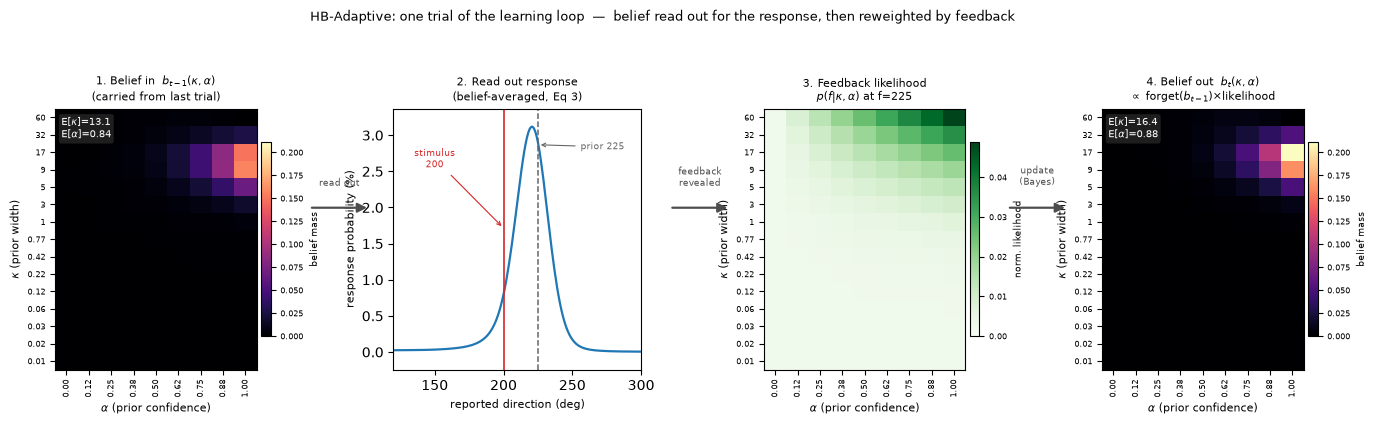

SLIDE (equation-explainer) CLAIMS:
  - Eq 3 read-out peaks at 221 deg, between stimulus 200 and prior 225 (prior attraction)
  - Eq 2 update sharpens belief: E[k] 13.1->16.4, E[a] 0.84->0.88
  - response is read out BEFORE feedback (no within-trial leakage); feedback only moves the NEXT belief


In [7]:
# --- 2.4a · One trial of the learning loop (Eq 1 read-out -> Eq 2 update) ---
# Regenerates the single-trial figure: belief in -> response -> feedback likelihood -> belief out.
import numpy as np, os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import PowerNorm
from observers.models.hb_adaptive_confidence import HBAdaptiveConfidenceObserver
from observers.models.hb_rachel import mixture_prior           # Eq 1
from observers.helpers.belief_grid import forget, bayes_correct  # Eq 2
from observers.helpers.circular import von_mises_pdfs, DIRECTION_SPACE

obs = HBAdaptiveConfidenceObserver()
kg, ag = obs.k_grid, obs.a_grid
K, A = np.meshgrid(kg, ag, indexing="ij"); kap, alp = K.ravel(), A.ravel(); G = kap.size
# feedback-likelihood table: row g = pair g's mixed prior over 360 dirs; p(f|k,a) = column f
table = np.vstack([mixture_prior(kap[g], alp[g], 225.0) for g in range(G)])

# build a mid-block belief from 6 feedbacks sampled from an SD~20 prior at 225
rng = np.random.RandomState(3)
pfb = von_mises_pdfs(DIRECTION_SPACE, 225.0, 8.0, normalize=True).ravel()
b_in = np.ones(G) / G
for f in rng.choice(np.arange(1, 361), size=6, p=pfb):
    b_in = bayes_correct(forget(b_in, np.ones(G)/G, obs.lam), table[:, f-1])

trial_dir, trial_coh, feedback = 200, 0.12, 225
obs._prepare(np.array([trial_dir]), np.array([trial_coh]))
resp = obs.estimate_distribution(trial_coh, trial_dir, b_in)     # Eq 3 read-out (behavioural output)
like = table[:, feedback-1]                                      # Eq 2 correct term
b_out = bayes_correct(forget(b_in, np.ones(G)/G, obs.lam), like) # Eq 2 full update
Ek = lambda b: float((b*kap).sum()); Ea = lambda b: float((b*alp).sum())

klab = [f"{v:.2f}" if v < 1 else f"{v:.0f}" for v in kg]; alab = [f"{v:.2f}" for v in ag]
vmax = max(b_in.max(), b_out.max())
fig = plt.figure(figsize=(13.5, 4.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1.15, 1, 1], wspace=0.55,
                      left=0.05, right=0.985, bottom=0.16, top=0.74)
axA, axB, axC, axD = [fig.add_subplot(gs[i]) for i in range(4)]

def grid(ax, b, title, cmap, vmax, e=True):
    im = ax.imshow(b.reshape(15, 9), origin="lower", aspect="auto", cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(9)); ax.set_xticklabels(alab, rotation=90, fontsize=6)
    ax.set_yticks(range(15)); ax.set_yticklabels(klab, fontsize=6)
    ax.set_xlabel(r"$\alpha$ (prior confidence)", fontsize=8); ax.set_ylabel(r"$\kappa$ (prior width)", fontsize=8)
    ax.set_title(title, fontsize=8, linespacing=1.35)
    if e:
        ax.text(0.03, 0.97, f"E[$\\kappa$]={Ek(b):.1f}\nE[$\\alpha$]={Ea(b):.2f}", transform=ax.transAxes,
                ha="left", va="top", fontsize=7, color="white",
                bbox=dict(boxstyle="round,pad=0.25", fc="0.15", ec="none", alpha=0.8))
    return im

imA = grid(axA, b_in, "1. Belief in  $b_{t-1}(\\kappa,\\alpha)$\n(carried from last trial)", "magma", vmax)
d = np.arange(1, 361)
axB.plot(d, resp*100, color="#1f77b4", lw=1.6)
axB.axvline(trial_dir, color="#d62728", lw=1.2); axB.axvline(225, color="0.4", lw=1.1, ls="--")
axB.set_xlim(120, 300); axB.margins(y=0.08)
axB.set_xlabel("reported direction (deg)", fontsize=8); axB.set_ylabel("response probability (%)", fontsize=8)
axB.set_title("2. Read out response\n(belief-averaged, Eq 3)", fontsize=8, linespacing=1.35)
axB.annotate("stimulus\n200", xy=(trial_dir, (resp*100).max()*0.55), xytext=(150, (resp*100).max()*0.82),
             fontsize=6.8, color="#d62728", ha="center", arrowprops=dict(arrowstyle="->", color="#d62728", lw=0.8))
axB.annotate("prior 225", xy=(225, (resp*100).max()*0.92), xytext=(272, (resp*100).max()*0.9),
             fontsize=6.8, color="0.4", ha="center", arrowprops=dict(arrowstyle="->", color="0.4", lw=0.8))
imC = grid(axC, like/like.sum(), f"3. Feedback likelihood\n$p(f|\\kappa,\\alpha)$ at f={feedback}", "Greens", (like/like.sum()).max(), e=False)
imD = grid(axD, b_out, "4. Belief out  $b_t(\\kappa,\\alpha)$\n$\\propto$ forget($b_{t-1}$)$\\times$likelihood", "magma", vmax)
for im_, ax_, lb in [(imA, axA, "belief mass"), (imC, axC, "norm. likelihood"), (imD, axD, "belief mass")]:
    cb = fig.colorbar(im_, ax=[ax_], fraction=0.045, pad=0.02); cb.ax.tick_params(labelsize=6); cb.set_label(lb, fontsize=6.5)
for x0, x1, lab in [(0.238, 0.283, "read out"), (0.505, 0.55, "feedback\nrevealed"), (0.755, 0.80, "update\n(Bayes)")]:
    fig.add_artist(FancyArrowPatch((x0, 0.52), (x1, 0.52), transform=fig.transFigure,
                   arrowstyle="-|>", mutation_scale=14, lw=1.6, color="0.3", clip_on=False))
    fig.text((x0+x1)/2, 0.565, lab, ha="center", va="bottom", fontsize=6.8, color="0.3", linespacing=1.2)
fig.suptitle("HB-Adaptive: one trial of the learning loop  —  belief read out for the response, then reweighted by feedback", fontsize=9.5, y=0.96)
fig.savefig(os.path.join(FIG_DIR, "hb_adaptive_single_trial.png"), dpi=200, bbox_inches="tight")
plt.show()

print("SLIDE (equation-explainer) CLAIMS:")
print(f"  - Eq 3 read-out peaks at {int(resp.argmax())+1} deg, between stimulus 200 and prior 225 (prior attraction)")
print(f"  - Eq 2 update sharpens belief: E[k] {Ek(b_in):.1f}->{Ek(b_out):.1f}, E[a] {Ea(b_in):.2f}->{Ea(b_out):.2f}")
print(f"  - response is read out BEFORE feedback (no within-trial leakage); feedback only moves the NEXT belief")


**2.4b — Learning across a real block.** The belief update (Eq 2) run over subject 1's actual
trial sequence with their fitted parameters. Block 3 is an SD 20° block that immediately follows
an SD 80° block, so the belief **walks in wide** (carried across the boundary — there is no reset,
only λ-forgetting) and **re-narrows** to the new block. Confidence in the prior recovers fast;
the believed width settles more slowly and noisily around the true 20°.

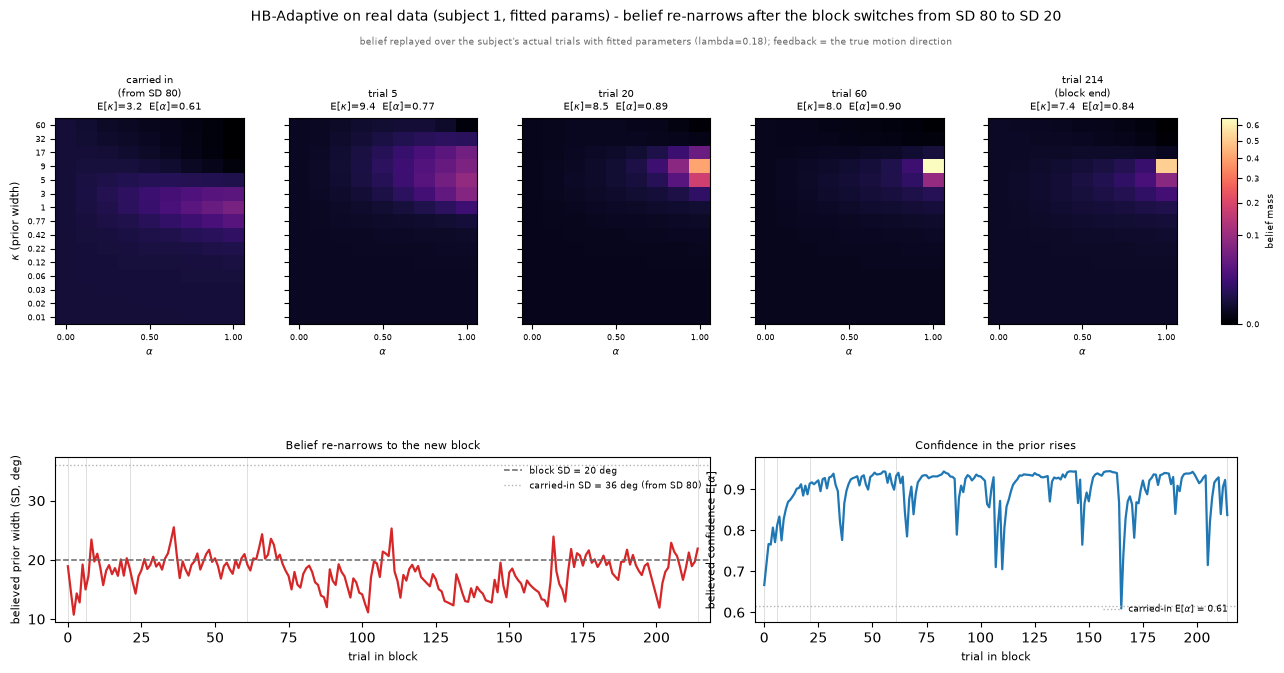

SLIDE (equation-explainer) CLAIMS:
  - belief CARRIES across block boundary: walks in at believed SD=36 deg (from the SD-80 block)
  - re-narrows over the SD-20 block to believed SD=22 deg (true block SD 20)
  - confidence E[a] rises 0.61 -> 0.84; dips = trials whose feedback landed far from 225


In [8]:
# --- 2.4b · The belief learning across a REAL block (subject 1, fitted params) ---
# Regenerates the block-evolution figure on the subject's actual trials. The belief carries
# ACROSS the block boundary (SD 80 -> SD 20) and re-narrows; no reset, just lambda-forgetting.
import numpy as np, os, json
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from observers.models.hb_adaptive_confidence import HBAdaptiveConfidenceObserver
from observers.helpers.circular import von_mises_std
from observers.helpers.paths import DATA_CSV

fit = json.load(open(os.path.join(ROOT, "results/fits/comparison/hb_adaptive/subject1.json")))
p = fit["params"]
obs = HBAdaptiveConfidenceObserver(
    k_like={0.06: p["k_like"]["0.06"], 0.12: p["k_like"]["0.12"], 0.24: p["k_like"]["0.24"]},
    k_motor=p["k_motor"], p_random=p["p_random"], lam=p["lam"])

df = pd.read_csv(DATA_CSV)
s = df[df.subject_id == 1].dropna(subset=["motion_direction","prior_std","motion_coherence"]).reset_index(drop=True)
dirs = s.motion_direction.to_numpy(int); cohs = s.motion_coherence.to_numpy(float)
blk = (s.prior_std != s.prior_std.shift()).cumsum().to_numpy()

obs._prepare(dirs, cohs)
kap, alp = obs._joint_grid(); G = kap.size
b = obs._belief0.copy(); beliefs = [b.copy()]
for t in range(dirs.size):
    b = obs.update_belief(b, dirs[t]); beliefs.append(b.copy())
Ek = np.array([(bb*kap).sum() for bb in beliefs]); Ea = np.array([(bb*alp).sum() for bb in beliefs])
sd = np.array([von_mises_std(max(k,1e-6),225.0) for k in Ek])

idx = np.where(blk == 3)[0]; b0i, b1i = idx.min(), idx.max()      # block 3: SD20 after SD80
kg, ag = obs.k_grid, obs.a_grid
klab = [f"{v:.2f}" if v < 1 else f"{v:.0f}" for v in kg]; alab = [f"{v:.2f}" for v in ag]
snap_off = [0, 6, 21, 61, b1i-b0i+1]
snaps = [beliefs[b0i], beliefs[b0i+6], beliefs[b0i+21], beliefs[b0i+61], beliefs[b1i+1]]
lbls = ["carried in\n(from SD 80)", "trial 5", "trial 20", "trial 60", f"trial {len(idx)-1}\n(block end)"]
sEk = [Ek[b0i], Ek[b0i+6], Ek[b0i+21], Ek[b0i+61], Ek[b1i+1]]
sEa = [Ea[b0i], Ea[b0i+6], Ea[b0i+21], Ea[b0i+61], Ea[b1i+1]]
vmax = max(x.max() for x in snaps)

fig = plt.figure(figsize=(13.5, 7.0))
gs = fig.add_gridspec(2, 6, height_ratios=[1, 0.8], width_ratios=[1,1,1,1,1,0.08],
                      left=0.055, right=0.93, bottom=0.08, top=0.80, hspace=0.72, wspace=0.28)
norm = PowerNorm(0.45, vmin=0, vmax=vmax)
for i,(bb,lbl,ek,ea) in enumerate(zip(snaps,lbls,sEk,sEa)):
    ax = fig.add_subplot(gs[0,i])
    im = ax.imshow(bb.reshape(15,9), origin="lower", aspect="auto", cmap="magma", norm=norm)
    ax.set_title(f"{lbl}\nE[$\\kappa$]={ek:.1f}  E[$\\alpha$]={ea:.2f}", fontsize=7.4, linespacing=1.35)
    ax.set_xticks([0,4,8]); ax.set_xticklabels([alab[0],alab[4],alab[8]], fontsize=6)
    ax.set_yticks(range(15)); ax.set_yticklabels(klab if i==0 else [], fontsize=6)
    if i==0: ax.set_ylabel(r"$\kappa$ (prior width)", fontsize=8)
    ax.set_xlabel(r"$\alpha$", fontsize=7)
cb = fig.colorbar(im, cax=fig.add_subplot(gs[0,5])); cb.ax.tick_params(labelsize=6); cb.set_label("belief mass", fontsize=6.5)

axK = fig.add_subplot(gs[1,0:3]); axAx = fig.add_subplot(gs[1,3:6]); xin = np.arange(len(idx))
axK.plot(xin, sd[b0i+1:b1i+2], color="#d62728", lw=1.6)
axK.axhline(20, color="0.4", ls="--", lw=1.1, label="block SD = 20 deg")
axK.axhline(sd[b0i], color="0.7", ls=":", lw=1.0, label=f"carried-in SD = {sd[b0i]:.0f} deg (from SD 80)")
axK.set_xlabel("trial in block", fontsize=8); axK.set_ylabel("believed prior width (SD, deg)", fontsize=8)
axK.set_title("Belief re-narrows to the new block", fontsize=8); axK.margins(x=0.02)
axK.legend(frameon=False, fontsize=6.6, loc="upper right")
axAx.plot(xin, Ea[b0i+1:b1i+2], color="#1f77b4", lw=1.6)
axAx.axhline(Ea[b0i], color="0.7", ls=":", lw=1.0, label=f"carried-in E[$\\alpha$] = {Ea[b0i]:.2f}")
axAx.set_xlabel("trial in block", fontsize=8); axAx.set_ylabel(r"believed confidence E[$\alpha$]", fontsize=8)
axAx.set_title("Confidence in the prior rises", fontsize=8); axAx.margins(x=0.02, y=0.1)
axAx.legend(frameon=False, fontsize=6.6, loc="lower right")
for r in snap_off:
    axK.axvline(min(r,len(idx)-1), color="0.88", lw=0.7, zorder=0); axAx.axvline(min(r,len(idx)-1), color="0.88", lw=0.7, zorder=0)
fig.suptitle("HB-Adaptive on real data (subject 1, fitted params) - belief re-narrows after the block switches from SD 80 to SD 20", fontsize=9.8, y=0.955)
fig.text(0.5, 0.905, f"belief replayed over the subject's actual trials with fitted parameters (lambda={p['lam']:.2f}); feedback = the true motion direction", ha="center", fontsize=6.8, color="0.4")
fig.savefig(os.path.join(FIG_DIR, "hb_adaptive_real_block_subject1.png"), dpi=200, bbox_inches="tight")
plt.show()

print("SLIDE (equation-explainer) CLAIMS:")
print(f"  - belief CARRIES across block boundary: walks in at believed SD={sd[b0i]:.0f} deg (from the SD-80 block)")
print(f"  - re-narrows over the SD-20 block to believed SD={sd[b1i+1]:.0f} deg (true block SD 20)")
print(f"  - confidence E[a] rises {Ea[b0i]:.2f} -> {Ea[b1i+1]:.2f}; dips = trials whose feedback landed far from 225")


**2.4c — Belief vs. confidence vs. width.** The trajectory panels elsewhere plot two squiggly
lines, E[α] and E[κ]→SD. This figure shows they are not separate quantities the model tracks:
they are the two **marginals** of the single belief grid `b(κ,α)`. Sum the grid over κ (collapse
the rows) → the α-marginal, whose center of mass is *confidence* E[α]. Sum over α (collapse the
columns) → the κ-marginal, whose center of mass is *width* E[κ]. The squiggles are this grid
crushed onto one axis, one point per trial.

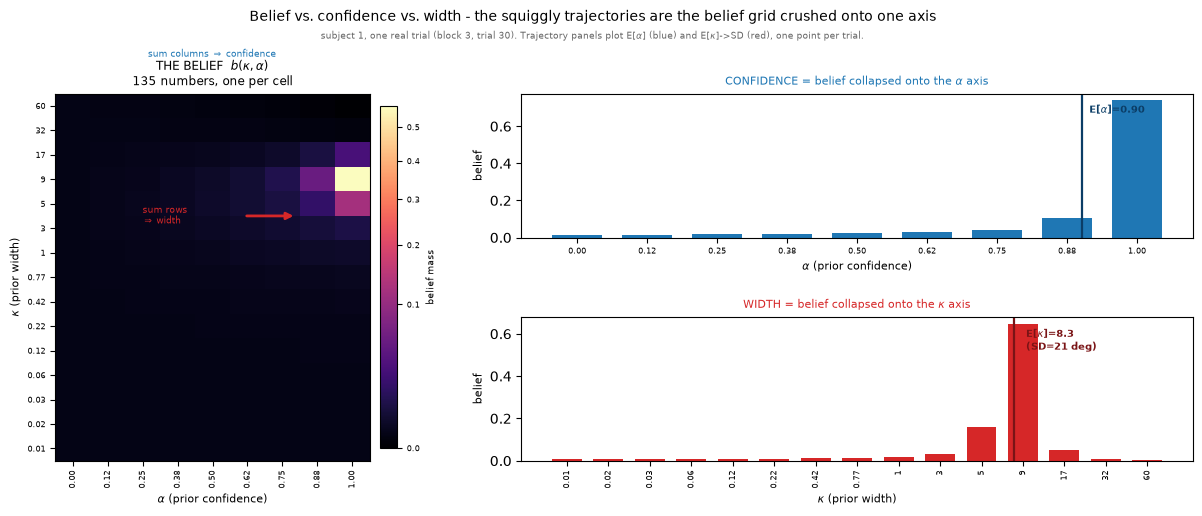

SLIDE (equation-explainer) CLAIMS:
  - the belief is ONE 2-D grid; confidence and width are its two marginals (row/column sums)
  - confidence = E[alpha] = 0.90 (center of mass of the alpha-marginal)
  - width = E[kappa] = 8.3 -> believed SD = 21 deg (center of mass of the kappa-marginal)


In [9]:
# --- 2.4c · Belief vs. confidence vs. width (what the squiggly trajectories mean) ---
# CONFIDENCE and WIDTH are not separate quantities: they are the two marginals of the ONE
# belief grid. Sum the grid over kappa -> confidence (E[alpha]); sum over alpha -> width (E[kappa]).
import numpy as np, os, json
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from observers.models.hb_adaptive_confidence import HBAdaptiveConfidenceObserver
from observers.helpers.circular import von_mises_std
from observers.helpers.paths import DATA_CSV

fit = json.load(open(os.path.join(ROOT, "results/fits/comparison/hb_adaptive/subject1.json"))); p = fit["params"]
obs = HBAdaptiveConfidenceObserver(
    k_like={0.06: p["k_like"]["0.06"], 0.12: p["k_like"]["0.12"], 0.24: p["k_like"]["0.24"]},
    k_motor=p["k_motor"], p_random=p["p_random"], lam=p["lam"])
df = pd.read_csv(DATA_CSV)
s = df[df.subject_id == 1].dropna(subset=["motion_direction","prior_std","motion_coherence"]).reset_index(drop=True)
dirs = s.motion_direction.to_numpy(int); cohs = s.motion_coherence.to_numpy(float)
blk = (s.prior_std != s.prior_std.shift()).cumsum().to_numpy()
obs._prepare(dirs, cohs); kap, alp = obs._joint_grid()
b = obs._belief0.copy(); beliefs = [b.copy()]
for t in range(dirs.size):
    b = obs.update_belief(b, dirs[t]); beliefs.append(b.copy())

b0i = np.where(blk == 3)[0].min(); t_show = b0i + 30
b_show = beliefs[t_show]; M = b_show.reshape(15, 9)
alpha_marg = M.sum(axis=0); kappa_marg = M.sum(axis=1)          # the two marginals
Ea_h = float((b_show*alp).sum()); Ek_h = float((b_show*kap).sum()); sd_h = von_mises_std(max(Ek_h,1e-6),225.0)
kg, ag = obs.k_grid, obs.a_grid
klab = [f"{v:.2f}" if v < 1 else f"{v:.0f}" for v in kg]; alab = [f"{v:.2f}" for v in ag]

fig = plt.figure(figsize=(12.5, 5.4))
gs = fig.add_gridspec(2, 3, width_ratios=[1.25,1,1], left=0.07, right=0.98, bottom=0.12, top=0.80, hspace=0.55, wspace=0.42)
axG = fig.add_subplot(gs[:,0])
im = axG.imshow(M, origin="lower", aspect="auto", cmap="magma", norm=PowerNorm(0.5, vmin=0, vmax=M.max()))
axG.set_xticks(range(9)); axG.set_xticklabels(alab, rotation=90, fontsize=6)
axG.set_yticks(range(15)); axG.set_yticklabels(klab, fontsize=6)
axG.set_xlabel(r"$\alpha$ (prior confidence)", fontsize=8); axG.set_ylabel(r"$\kappa$ (prior width)", fontsize=8)
axG.set_title("THE BELIEF  $b(\\kappa,\\alpha)$\n135 numbers, one per cell", fontsize=8.5, linespacing=1.3)
cb = fig.colorbar(im, ax=axG, fraction=0.05, pad=0.03); cb.ax.tick_params(labelsize=6); cb.set_label("belief mass", fontsize=6.5)
axG.annotate("", xy=(4,15.6), xytext=(4,14.0), arrowprops=dict(arrowstyle="-|>", color="#1f77b4", lw=2))
axG.text(4, 16.0, "sum columns $\\Rightarrow$ confidence", color="#1f77b4", fontsize=6.6, ha="center")
axG.annotate("", xy=(6.4,9.5), xytext=(4.9,9.5), arrowprops=dict(arrowstyle="-|>", color="#d62728", lw=2))
axG.text(2.0, 9.5, "sum rows\n$\\Rightarrow$ width", color="#d62728", fontsize=6.4, ha="left", va="center")

axAa = fig.add_subplot(gs[0,1:]); axAa.bar(range(9), alpha_marg, color="#1f77b4", width=0.72)
axAa.axvline(Ea_h*8, color="#0b3d66", lw=1.6); axAa.set_xticks(range(9)); axAa.set_xticklabels(alab, fontsize=6)
axAa.set_xlabel(r"$\alpha$ (prior confidence)", fontsize=8); axAa.set_ylabel("belief", fontsize=8)
axAa.set_title("CONFIDENCE = belief collapsed onto the $\\alpha$ axis", fontsize=8, color="#1f77b4")
axAa.text(Ea_h*8, axAa.get_ylim()[1]*0.92, f"  E[$\\alpha$]={Ea_h:.2f}", color="#0b3d66", fontsize=7.2, ha="left", va="top", fontweight="bold")
axKk = fig.add_subplot(gs[1,1:]); axKk.bar(range(15), kappa_marg, color="#d62728", width=0.72)
axKk.axvline(np.interp(Ek_h, kg, range(15)), color="#7a1416", lw=1.6)
axKk.set_xticks(range(15)); axKk.set_xticklabels(klab, rotation=90, fontsize=6)
axKk.set_xlabel(r"$\kappa$ (prior width)", fontsize=8); axKk.set_ylabel("belief", fontsize=8)
axKk.set_title("WIDTH = belief collapsed onto the $\\kappa$ axis", fontsize=8, color="#d62728")
axKk.text(np.interp(Ek_h,kg,range(15))+0.3, axKk.get_ylim()[1]*0.92, f"E[$\\kappa$]={Ek_h:.1f}\n(SD={sd_h:.0f} deg)", color="#7a1416", fontsize=7.2, ha="left", va="top", fontweight="bold")
fig.suptitle("Belief vs. confidence vs. width - the squiggly trajectories are the belief grid crushed onto one axis", fontsize=10, y=0.955)
fig.text(0.5, 0.90, f"subject 1, one real trial (block 3, trial {t_show-b0i}). Trajectory panels plot E[$\\alpha$] (blue) and E[$\\kappa$]->SD (red), one point per trial.", ha="center", fontsize=6.8, color="0.4")
fig.savefig(os.path.join(FIG_DIR, "hb_adaptive_belief_marginals_explainer.png"), dpi=200, bbox_inches="tight")
plt.show()

print("SLIDE (equation-explainer) CLAIMS:")
print(f"  - the belief is ONE 2-D grid; confidence and width are its two marginals (row/column sums)")
print(f"  - confidence = E[alpha] = {Ea_h:.2f} (center of mass of the alpha-marginal)")
print(f"  - width = E[kappa] = {Ek_h:.1f} -> believed SD = {sd_h:.0f} deg (center of mass of the kappa-marginal)")
